In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import getFamaFrenchFactors as gff

In [2]:
rets = yf.download(['VTI','AVUV'], interval = '1mo', auto_adjust = True, start = '2000-01-01')['Close']
rets = rets.to_period('M').pct_change().dropna()

[*********************100%***********************]  1 of 2 completed


In [8]:
rets.tail()

Ticker,AVUV,VTI
Date,,
2026-03,-0.019698,-0.050048
2026-04,0.087535,0.104018
2026-05,-0.000749,0.051838
2026-06,0.043055,-0.003853
2026-07,0.011542,-0.012625


In [5]:
ff_5f_model = gff.famaFrench5Factor().set_index('date_ff_factors').to_period('M')

In [9]:
ff_5f_model.tail()

,Mkt-RF,SMB,HML,RMW,CMA,RF
date_ff_factors,,,,,,
2026-01,0.0103,0.0321,0.0382,0.0180,0.0181,0.0030
2026-02,-0.0118,0.0075,0.0271,0.0191,0.0504,0.0028
2026-03,-0.0518,0.0066,0.0341,-0.0208,-0.0010,0.0029
2026-04,0.0995,0.0038,-0.0117,-0.0430,-0.0378,0.0029
2026-05,0.0490,-0.0277,-0.0215,-0.0842,-0.0139,0.0031


<Axes: xlabel='date_ff_factors'>

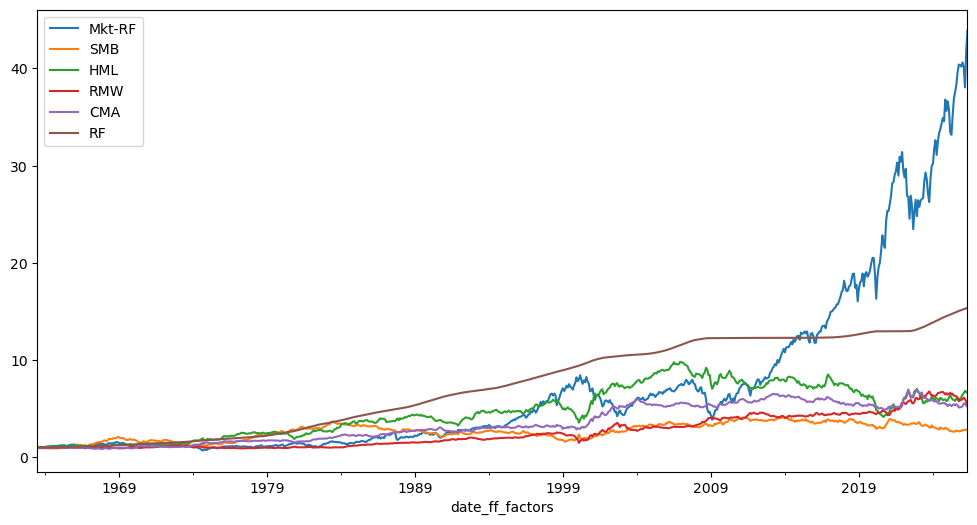

In [10]:
(1+ff_5f_model).cumprod().plot(figsize=(12,6))